# Part 4 — Vector Databases: Embeddings Demo

This notebook:
1. Defines **10 sentences** across 3 topics: **Cricket**, **Cooking**, **Cybersecurity**
2. Generates embeddings using `sentence-transformers` model `all-MiniLM-L6-v2`
3. Computes and visualizes a **10×10 cosine similarity heatmap**
4. Finds the **top 2 most similar sentences** to a new query

In [1]:
!pip install sentence-transformers -q

In [2]:
# ── Cell 2: Define 10 sentences across 3 topics ───────────────────────────

sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent century in the final over.",
    "India won the match by six wickets against Australia.",
    "The spinner delivered a sharp googly that confused the batsman.",
    "A dropped catch in the slips cost the team the match.",

    # Cooking (4 sentences)
    "Saute the onions in olive oil until they turn golden brown.",
    "Marinating the chicken overnight gives it a deeper, richer flavour.",
    "Always bring the water to a rolling boil before adding pasta.",
    "A pinch of saffron transforms a simple biryani into something extraordinary.",

    # Cybersecurity (2 sentences)
    "The hacker exploited a SQL injection vulnerability in the web application.",
    "Two-factor authentication significantly reduces the risk of account compromise."
]

labels = [
    "[Cricket] Batsman century",
    "[Cricket] India wins",
    "[Cricket] Googly delivery",
    "[Cricket] Dropped catch",
    "[Cooking] Saute onions",
    "[Cooking] Marinate chicken",
    "[Cooking] Boil pasta",
    "[Cooking] Saffron biryani",
    "[Cyber] SQL injection",
    "[Cyber] 2FA security"
]

topics = ["Cricket"]*4 + ["Cooking"]*4 + ["Cybersecurity"]*2

print(f"Total sentences: {len(sentences)}")
for i, (s, t) in enumerate(zip(sentences, topics)):
    print(f"[{i}] ({t}) {s}")

Total sentences: 10
[0] (Cricket) The batsman hit a magnificent century in the final over.
[1] (Cricket) India won the match by six wickets against Australia.
[2] (Cricket) The spinner delivered a sharp googly that confused the batsman.
[3] (Cricket) A dropped catch in the slips cost the team the match.
[4] (Cooking) Saute the onions in olive oil until they turn golden brown.
[5] (Cooking) Marinating the chicken overnight gives it a deeper, richer flavour.
[6] (Cooking) Always bring the water to a rolling boil before adding pasta.
[7] (Cooking) A pinch of saffron transforms a simple biryani into something extraordinary.
[8] (Cybersecurity) The hacker exploited a SQL injection vulnerability in the web application.
[9] (Cybersecurity) Two-factor authentication significantly reduces the risk of account compromise.


In [3]:
# ── Cell 3: Generate embeddings using all-MiniLM-L6-v2 ────────────────────

from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading model: all-MiniLM-L6-v2...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

embeddings = model.encode(sentences, normalize_embeddings=True)
print(f"Embeddings shape: {embeddings.shape}")
print("Each sentence is represented as a 384-dimensional vector.")

Loading model: all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Embeddings shape: (10, 384)
Each sentence is represented as a 384-dimensional vector.


In [4]:
# ── Cell 4: Compute 10x10 cosine similarity matrix ────────────────────────

import pandas as pd

# Since embeddings are L2-normalized, dot product == cosine similarity
sim_matrix = np.dot(embeddings, embeddings.T)

short_labels = [f"S{i}" for i in range(10)]
df_sim = pd.DataFrame(sim_matrix, index=short_labels, columns=short_labels)

print("10x10 Cosine Similarity Matrix:")
print(df_sim.round(3).to_string())

10x10 Cosine Similarity Matrix:
       S0     S1     S2     S3     S4     S5     S6     S7     S8     S9
S0  1.000  0.569  0.527  0.242  0.038  0.031 -0.028  0.065  0.052 -0.009
S1  0.569  1.000  0.374  0.297  0.020  0.015 -0.040  0.044  0.078 -0.061
S2  0.527  0.374  1.000  0.303  0.061  0.063  0.012  0.142  0.181 -0.006
S3  0.242  0.297  0.303  1.000 -0.062  0.011  0.003  0.136  0.116  0.048
S4  0.038  0.020  0.061 -0.062  1.000  0.227  0.306  0.095  0.025 -0.099
S5  0.031  0.015  0.063  0.011  0.227  1.000  0.284  0.124  0.069  0.042
S6 -0.028 -0.040  0.012  0.003  0.306  0.284  1.000  0.100  0.126  0.002
S7  0.065  0.044  0.142  0.136  0.095  0.124  0.100  1.000  0.138  0.069
S8  0.052  0.078  0.181  0.116  0.025  0.069  0.126  0.138  1.000  0.182
S9 -0.009 -0.061 -0.006  0.048 -0.099  0.042  0.002  0.069  0.182  1.000


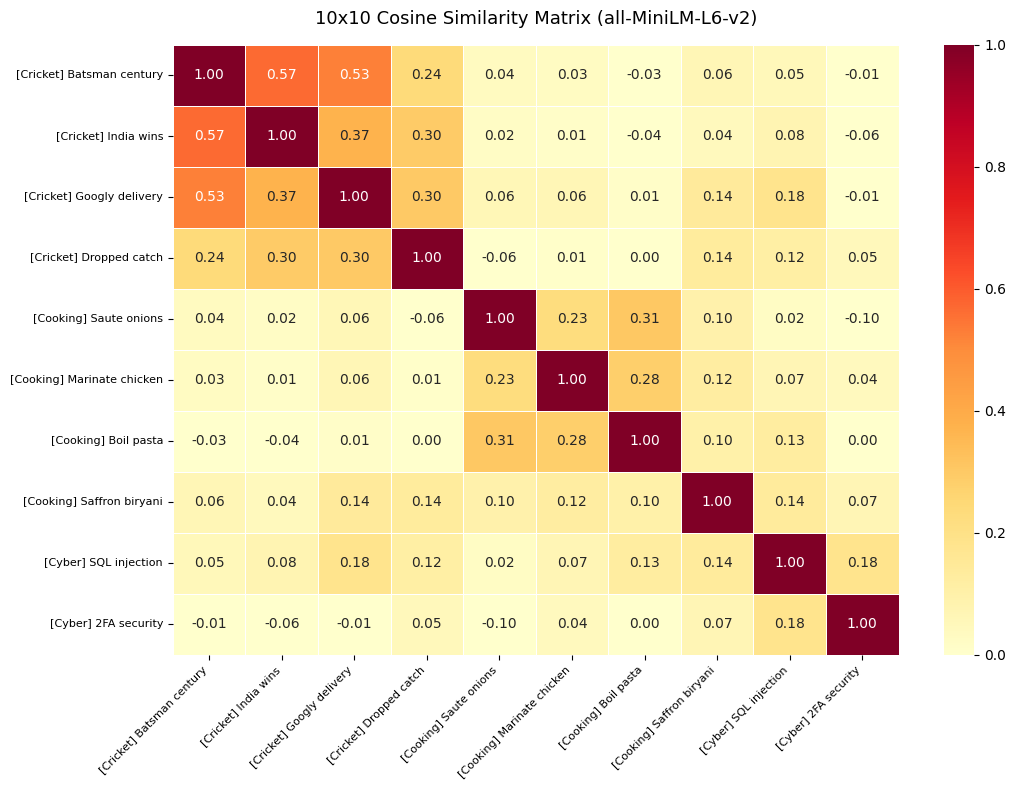

Heatmap saved as similarity_heatmap.png


In [5]:
# ── Cell 5: Visualize as heatmap ──────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    df_sim,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title("10x10 Cosine Similarity Matrix (all-MiniLM-L6-v2)", fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved as similarity_heatmap.png")

In [6]:
# ── Cell 6: Find top 2 most similar sentences to the query ────────────────

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query], normalize_embeddings=True)
similarities = np.dot(query_embedding, embeddings.T)[0]

top2 = np.argsort(similarities)[::-1][:2]

print(f"Query: '{query}'")
print("=" * 60)
print("Top 2 most similar sentences:\n")
for rank, idx in enumerate(top2, 1):
    print(f"Rank {rank}")
    print(f"  Similarity Score : {similarities[idx]:.4f}")
    print(f"  Sentence         : {sentences[idx]}")
    print(f"  Topic            : {topics[idx]}")
    print()

print("Observation: Both top matches belong to the Cricket topic,")
print("confirming the model captures semantic meaning correctly.")

Query: 'The bowler took three wickets in one over'
Top 2 most similar sentences:

Rank 1
  Similarity Score : 0.6433
  Sentence         : India won the match by six wickets against Australia.
  Topic            : Cricket

Rank 2
  Similarity Score : 0.5936
  Sentence         : The batsman hit a magnificent century in the final over.
  Topic            : Cricket

Observation: Both top matches belong to the Cricket topic,
confirming the model captures semantic meaning correctly.
